Fly Ergo Fly

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
from numpy import loadtxt
from scipy import signal
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from os import scandir, getcwd
import os
from os import remove
from numpy import asarray
from numpy import savetxt
import shutil

In [ ]:
input_dir = 'path1'
output = 'path2'
error = 'path3'

In [ ]:
os.chdir(input_dir) 
names = []
pos = 0
for root, dirs, files in os.walk("."):
    for filename in files:
        names.append(filename)
        print("posicion %d: %s" %(pos, names[pos]))
        pos = pos + 1

In [ ]:
### En esta parte calculamos los parámetros de nuestros electrorretinogramas. 
### Dependiendo del ruido de los registros y las condiciones algunos parámetros
### han de ser modificados

def func_pol_1(x, a, b):
    return (a*x + b)

def func_pol_3(x, a, b, c, d):
    return (a*x**3 + b*x**2 + c*x + d)

def func_pol_4(x, a, b, c, d, e):
    return (a*x**4 + b*x**3 + c*x**2 + d*x + e)

values = []

h_on = 0 #############################(Límite on)###################################################
range_on = 100 #########################(rango dcha on)###################################################
limit_counter_on = 50
t_ini_on = 0

h_off = 0.0 ############################(Límite off)#################################################
range_off = 900 ####################(rango dcha búsqueda off)#####################################
range_off_mins = 50 #######################(rango mínimos off 50)##########################################
range_off_2 = 50 ####################(rango izqda búsqueda off 2)#####################################
min_off = 0.2 ##############(mínimo valor de off para que sea aceptado)##############################

h_AmpR = 1  #############################(height peaks AmpR)###################################################
l_AmpR = 180 ############################(length line plot OvS)############################################

h_OvS = 1  #############################(height peaks OvS)###################################################
l_OvS = 380 ############################(length line plot OvS)############################################

for i in range(len(names)):
    print(i)
    f = open(names[i], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    t = np.arange(len(mV))
    f.close()
    
    name = names[i]
    name = name.strip('.dat_.txt')
    
    strain = lines[14]
    strain = strain.strip('strain')
    strain = strain.strip('=')
    strain = strain.strip('\n')


    comment2 = lines[17]
    comment2 = comment2.strip('comment2')
    comment2 = comment2.strip('=')
    comment2 = comment2.strip('\n')
    
    comment = ''

    plt.figure(figsize=(14, 7), dpi=100)
    plt.ylim(-24, 12)
    plt.ylabel('mV')
    plt.xlabel('ms')
    plt.suptitle('%s: %s' %(strain, comment2))
    plt.plot(mV)

## En esta sección del programa determinaremos el AmpR, con base al momento del estímulo

    t_on = np.empty(0)
    peaks_on = np.empty(0)
    peaks_on, _ = find_peaks(mV[t_ini_on:], height= h_on)    
    B_on = False
    B_t_on = False
    if peaks_on.size > 0:
        for i_2 in range (len(peaks_on)):
            t_on = peaks_on[i_2] + t_ini_on
            counter_on = 0
            popt_on = np.empty(0)
            for i_3 in range (range_on):
                if peaks_on[i_2] + i_3 == len(t) - 1:
                    break
                if mV[peaks_on[i_2]+i_3] < 0:
                    counter_on = counter_on + 1
                if counter_on > limit_counter_on:
                    popt_on, pcov_on = curve_fit(func_pol_1, t[t_on:t_on+30], mV[t_on:t_on+30])
                    break
            if counter_on > limit_counter_on and popt_on.size > 0 and popt_on[0] < -0.04:            
                max_on = 50
                t_on = t_on + np.argmax(mV[t_on - max_on:t_on + max_on]) - max_on
                on = round(mV[t_on], 2)
                B_on = True
                B_t_on = True
                break               

    if not B_on:
        on = 0
        comment = 'Warning'                    
        for i_2_1 in range (len(t)):
            if len(mV[i_2_1:i_2_1+range_on]) == range_on:
                if np.all(mV[i_2_1:i_2_1+range_on] < 0):
                    popt_on_1, pcov_on_1 = curve_fit(func_pol_1, t[i_2_1:i_2_1+30], mV[i_2_1:i_2_1+30])
                    if popt_on_1.size > 0 and popt_on_1[0] < -0.04:
                        t_on = i_2_1
                        B_t_on = True
                        break 
    
    if B_t_on:
        plt.plot(t_on, on, color= 'orange',marker="x")
        plt.annotate('on = %.2f' %on, xy=(t_on - 400, on + 0.5))

        
## En esta sección del programa determinaremos el off, con base al momento del estímulo
        
    peaks_off = np.empty(0)  
    if B_t_on:
        peaks_off, _ = find_peaks(-mV[t_on : t_on+range_off], height= h_off)
        if peaks_off.size > 0:
            for i_4 in range (len(peaks_off)):
                off = 0
                t_off = peaks_off[-(i_4+1)] + t_on
                popt_off, pcov_off = curve_fit(func_pol_1, t[t_off:t_off+30], mV[t_off:t_off+30])
                B_off = False
                B_off_2 = False
                if popt_off[0] > 0.012:
                    t_off = t[t_off-range_off_mins + np.argmin(mV[t_off-range_off_mins : t_off])]
                    B_off = True
                    t_off_2 = t_off
                    for i_6 in range(t_off-range_off_2, t_off):
                        if mV[i_6] > mV[t_off_2]:
                            t_off_2 = t[i_6]
                            B_off_2 = True                            
                            off = round((mV[t_off_2]- mV[t_off]), 2)
                    for i_6_2 in range(t_off_2, t_off):
                        if mV[i_6_2] < mV[t_off]:
                            t_off = t[i_6_2]
                            off = round((mV[t_off_2]- mV[t_off]), 2)
                    if off > min_off:
                        if peaks_off[-(i_4+1)] - peaks_off[-(i_4+2)] > 2*range_off_mins:
                            break
                        if mV[peaks_off[-(i_4+1)] + t_on] < mV[peaks_off[-(i_4+2)] + t_on]:
                            break


    if B_off_2:
        plt.plot(t_off, mV[t_off], color= 'green', marker="x")
        plt.plot(t_off_2, mV[t_off_2], color= 'green', marker="x")
        plt.annotate('off = %.2f' %off, xy=(t_off-100, mV[t_off]-1))
#         plt.plot(peaks_off + t_on, mV[peaks_off + t_on], color= 'orange', marker="x")#################3
    else:
        comment = 'Warning'
        
                        
## En esta sección del programa determinaremos el OvS y su area, en base al momento del estímulo
        
    OvS = []
    area = []
    t_OvS_in = []
    t_OvS_end = []
    popt_OvS = np.empty(0)
    if B_t_on:
        if B_off_2:
            t_OvS_in = t_off
            for i_7 in range (t_off, len(t)):
                if len(mV[i_7:i_7+20]) == 20:
                    if np.all(mV[i_7:i_7+20] > 0):
                        t_OvS_in = i_7
                        break
            for i_8 in range (t_OvS_in, len(t)):              
                if len(mV[i_8:i_8+20]) == 20:
                    if np.all(mV[i_8:i_8+20] < 0):
                        break
            t_OvS_end = i_8
        else:            
            t_OvS_in = t_on
            for i_7_1 in range (t_on, len(t)):
                if len(mV[i_7_1:i_7_1+20]) == 20:
                    if np.all(mV[i_7_1:i_7_1+20] > 0):
                        t_OvS_in = i_7_1
                        break
            for i_8_1 in range (t_OvS_in, len(t)):              
                if len(mV[i_8_1:i_8_1+20]) == 20:
                    if np.all(mV[i_8_1:i_8_1+20] < 0):
                        break 
            t_OvS_end = i_8_1
        
        try:
            popt_OvS, pcov_OvS = curve_fit(func_pol_4, t[t_OvS_in:t_OvS_end], mV[t_OvS_in:t_OvS_end])
            y_OvS = func_pol_4(t[t_OvS_in:t_OvS_end], *popt_OvS)
            t_OvS = np.argmax(y_OvS) + t_OvS_in
            OvS = np.amax(y_OvS)
            OvS = round(OvS, 2)
            m_OvS = np.full((2*l_OvS, 1), OvS)
            m_t_OvS = np.arange(t_OvS-l_OvS, t_OvS+l_OvS)
            plt.plot(t[t_OvS_in:t_OvS_end], y_OvS, 'purple')
            plt.plot(m_t_OvS, m_OvS, color= 'red')
            plt.annotate('OvS = %.2f' %OvS, xy=(t_OvS-550, OvS+0.5))
            area = round(sum(mV[t_OvS_in:t_OvS_end]), 2)
            plt.plot(t[t_OvS_in:t_OvS_end], np.zeros_like(t[t_OvS_in:t_OvS_end]), color='black', linestyle="dashed")
            plt.annotate('Area = %.2f' %area, xy=(t_OvS-550, OvS/3))
        except (ValueError, RuntimeError, TypeError):
            OvS = np.nan      # Evitamos las listas vacías [] que rompen el CSV
            area = np.nan     # Evitamos las listas vacías []
            comment = "Warning: OvS fit failed"
        
        
## En esta sección del programa determinaremos el AmpR, en base al momento del estímulo

    AmpR = 0
    peaks_AmpR = np.empty(0)
    if B_t_on:
        if B_off_2:
            t_AmpR_in = t_on + int((t_off_2-t_on)/2) 
            for i_9 in reversed(range(t_on, t_AmpR_in)):
                popt_AmpR, pcov_AmpR = curve_fit(func_pol_3, t[i_9 :t_off_2], mV[i_9:t_off_2])
                if popt_AmpR.size > 0:
                    y_AmpR = func_pol_3(t[i_9:t_off_2], *popt_AmpR)
                    peaks_AmpR, _ = find_peaks(-y_AmpR, height= h_AmpR)            
                    if peaks_AmpR.size > 0:
                        t_AmpR = peaks_AmpR[0] + i_9
                        AmpR = y_AmpR[peaks_AmpR[0]]
                        AmpR = round(AmpR, 2)
                        m_AmpR = np.full((2*l_AmpR, 1), AmpR)
                        m_t_AmpR = np.arange(t_AmpR-l_AmpR, t_AmpR+l_AmpR)
                        plt.plot(m_t_AmpR, m_AmpR, color= 'red')
                        plt.annotate('AmpR = %.2f' %-AmpR, xy=(t_AmpR-200, AmpR-1))
                        plt.plot(t[i_9:t_off_2], y_AmpR, 'purple')
                        break
        else:
            if t_OvS_in:
                t_AmpR_in = t_on + int((t_off_2-t_OvS_in)/2)
                for i_9 in reversed(range(t_on, t_AmpR_in)):
                    popt_AmpR, pcov_AmpR = curve_fit(func_pol_3, t[i_9:t_OvS_in-150], mV[i_9:t_OvS_in -150])
                    y_AmpR = func_pol_3(t[i_9:t_OvS_in-150], *popt_AmpR)
                    peaks_AmpR, _ = find_peaks(-y_AmpR, height= h_AmpR)            
                    if peaks_AmpR.size > 0:
                        t_AmpR = peaks_AmpR[0] + i_9
                        AmpR = y_AmpR[peaks_AmpR[0]]
                        m_AmpR = np.full((2*l_AmpR, 1), AmpR)
                        m_t_AmpR = np.arange(t_AmpR-l_AmpR, t_AmpR+l_AmpR)
                        plt.plot(m_t_AmpR, m_AmpR, color= 'red')
                        plt.annotate('RPA = %.2f' %-AmpR, xy=(t_AmpR-200, AmpR-1))
                        plt.plot(t[i_9:t_OvS_in - 150], y_AmpR, 'purple')
                        break                        

    values.append((strain, comment2, on, off, -AmpR, OvS, area, t_on, t_off, t_off_2,
                   t_off-t_on, t_off-t_off_2, names[i], comment))
    
    plt.savefig("%s/%s.png" %(output, name), dpi=100)


## En esta sección del programa guardamos los parámetros

column_names = ['strain', 'condition', 'on', 'off', 'AmpR', 'OvS', 'area', 't_on', 't_off', 't_off_2',
                't_on_off', 't_off_dur', 'File', 'comment']
df = pd.DataFrame(values, columns=column_names)
df = df.sort_values(by=['strain', 'condition'], ignore_index=True)
df.to_csv('%s/data.csv' %output, index=False, sep=',')   


In [ ]:
### En esta parte importamos nuestra tabla con las métricas obtenidas ("data.csv")
### para evaluar el comportamiento de la población por genotipo y condición

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

os.chdir(output)
df = pd.read_csv('data.csv', decimal=',') 
df = df.sort_values(by=['strain', 'condition'], ignore_index=True)
grupos = df.groupby(['strain', 'condition'])

for (strain, condition), grupo in grupos:
    plt.figure(figsize=(14, 7), dpi=100)
    plt.ylim(-24, 12)
    plt.ylabel('mV')
    plt.xlabel('ms')
    plt.title(f'{strain}: {condition}')
    os.chdir(input_dir)   
    for idx, fila in grupo.iterrows():
        archivo = fila['File'] 
        if 't_on_off_2' in fila and fila['t_on_off_2'] < 0:
            continue   
        try:
            with open(archivo, mode='r', encoding='ISO-8859-15') as f:
                lines = f.readlines()
            mV = np.array(lines[19:], dtype=float)
            t_on = int(fila['t_on'])
            inicio = t_on - 400
            fin = t_on + 4000
            if fin > len(mV):
                fin = len(mV)
            if inicio < 0:
                inicio = 0
            mV_recortado = mV[inicio:fin]
            plt.plot(mV_recortado, label=archivo)            
        except Exception as e:
            print(f"No se pudo alinear el archivo {archivo}: {e}")
    plt.legend(loc='upper right', fontsize='xx-small', bbox_to_anchor=(1.15, 1))
    plt.tight_layout()
    
    os.chdir(output)
    nombre_fig = f"Fig_{strain.strip().replace(' ', '_')}_{condition.strip().replace(' ', '_')}.png"
    plt.savefig(nombre_fig, dpi=100)


In [ ]:
### En esta parte del código generamos una gráfica promedio representativa de la población

import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

os.chdir(output)
df = pd.read_csv('data.csv', decimal=',') 
df = df.sort_values(by=['strain', 'condition'], ignore_index=True)

grupos = df.groupby(['strain', 'condition'])
longitud_estandar = 4400 

for (strain, condition), grupo in grupos:
    senales_del_grupo = []
    os.chdir(input_dir)
    for idx, fila in grupo.iterrows():
        archivo = fila['File']        
        if 't_on_off_2' in fila and fila['t_on_off_2'] < 0:
            continue          
        try:
            with open(archivo, mode='r', encoding='ISO-8859-15') as f:
                lines = f.readlines()
            mV = np.array(lines[19:], dtype=float)
            t_on = int(fila['t_on'])
            inicio = t_on - 400
            fin = t_on + 4000
            if fin > len(mV): fin = len(mV)
            if inicio < 0: inicio = 0       
            mV_recortado = mV[inicio:fin]
            if len(mV_recortado) == longitud_estandar:
                senales_del_grupo.append(mV_recortado)
            
        except Exception as e:
            print(f"No se pudo procesar {archivo}: {e}")
    if len(senales_del_grupo) > 0:
        plt.figure(figsize=(14, 7), dpi=100)
        plt.ylim(-24, 12)
        plt.ylabel('mV')
        plt.xlabel('ms')
        plt.title(f'{strain}: {condition}')
        promedio_poblacion = np.mean(senales_del_grupo, axis=0)
        plt.plot(promedio_poblacion, color='blue', linewidth=2.5, label='PROMEDIO')
        plt.legend(loc='upper right')
        plt.tight_layout()
        os.chdir(output)
        nombre_fig = f"Fig_Promedio_{strain.strip().replace(' ', '_')}_{condition.strip().replace(' ', '_')}.png"
        plt.savefig(nombre_fig, dpi=100)
    else:
        print(f"No hay archivos suficientes para generar el promedio de {strain}: {condition}")


1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23


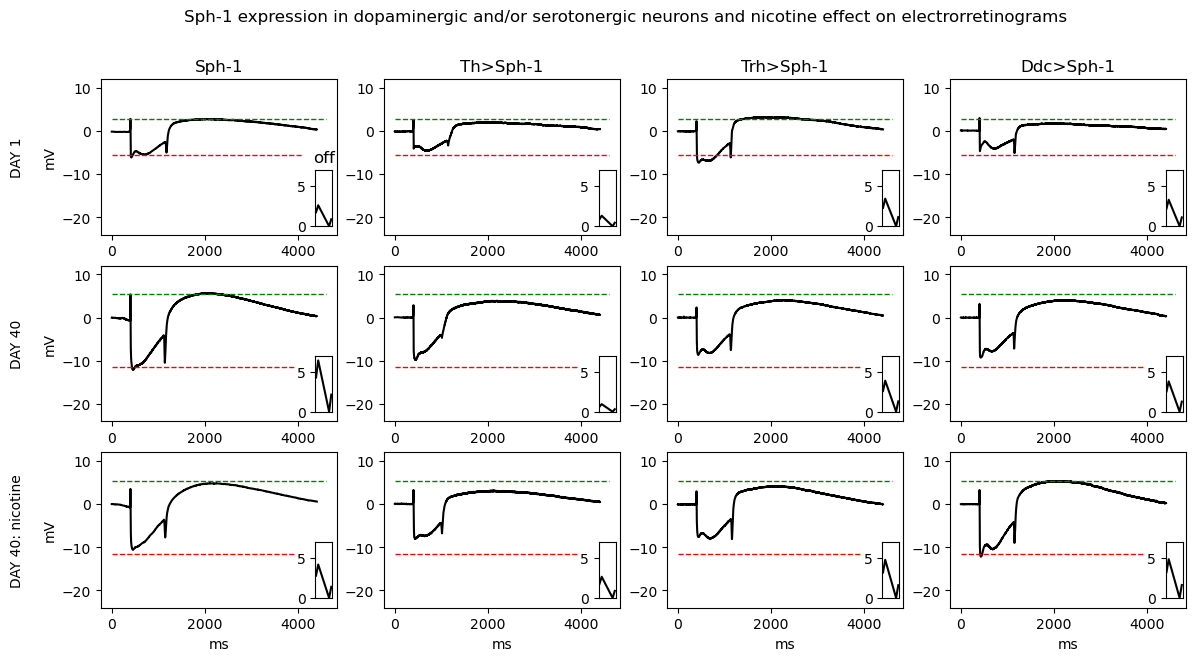

In [11]:
### En este bloque, esquematizamos el molde utilizado para la representación de la gráfica
### publicada en la figura 4 de https://doi.org/10.1371/journal.pone.0282348

import csv
with open('data.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

fig, ax = plt.subplots(figsize=(14, 7), dpi=100)
plt.suptitle("Sph-1 expression in dopaminergic and/or serotonergic neurons and nicotine effect on electrorretinograms")

plt.subplot(341)
plt.title("Sph-1")
plt.ylim(-24, 12)
plt.ylabel('DAY 1\n\nmV')


for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)

plt.plot([0, 4600], [2.81230769230769, 2.81230769230769], color='green', linewidth=1, linestyle="--", label = 'on Sph-1 Day 1')
plt.plot([0, 4050], [-5.52589743589743, -5.52589743589743], color='red', linewidth=1, linestyle="--", label = 'RPA Sph-1 Day 1')

ax1 = fig.add_axes([0.278, 0.67, 0.012, 0.08])
off = 2.61871794871795
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax1.plot(y_off, color='black')
ax1.set_title('off')
ax1.set_xticks([])
ax1.set_ylim(0, 7)

import csv
with open('data_2.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

plt.subplot(342)
plt.title("Th>Sph-1")
plt.ylim(-24, 12)

for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)

plt.plot([0, 4600], [2.81230769230769, 2.81230769230769], color='green', linewidth=1, linestyle="--", label = 'on Sph-1')
plt.plot([0, 4600], [-5.52589743589743, -5.52589743589743], color='red', linewidth=1, linestyle="--", label = 'RPA Sph-1')

ax2 = fig.add_axes([0.4805, 0.67, 0.012, 0.08])
off = 1.31190476190476
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax2.plot(y_off, color='black')
ax2.set_xticks([])
ax2.set_ylim(0, 7)


import csv
with open('data_3.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

plt.subplot(343)
plt.title("Trh>Sph-1")
plt.ylim(-24, 12)

for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)

plt.plot([0, 4600], [2.81230769230769, 2.81230769230769], color='green', linewidth=1, linestyle="--", label = 'on Sph-1')
plt.plot([0, 4600], [-5.52589743589743, -5.52589743589743], color='red', linewidth=1, linestyle="--", label = 'RPA Sph-1')

ax3 = fig.add_axes([0.683, 0.67, 0.012, 0.08])
off = 3.445
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax3.plot(y_off, color='black')
ax3.set_xticks([])
ax3.set_ylim(0, 7)



import csv
with open('data_4.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

plt.subplot(344)
plt.title("Ddc>Sph-1")
plt.ylim(-24, 12)

for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)

plt.plot([0, 4600], [2.81230769230769, 2.81230769230769], color='green', linewidth=1, linestyle="--", label = 'on Sph-1')
plt.plot([0, 4600], [-5.52589743589743, -5.52589743589743], color='red', linewidth=1, linestyle="--", label = 'RPA Sph-1')

ax4 = fig.add_axes([0.8855, 0.67, 0.012, 0.08])
off = 3.30935483870968
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax4.plot(y_off, color='black')
ax4.set_xticks([])
ax4.set_ylim(0, 7)



import csv
with open('data_5.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

plt.subplot(345)
plt.ylim(-24, 12)
plt.ylabel('DAY 40\n\nmV')

for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)

plt.plot([0, 4600], [5.35222222222222, 5.35222222222222], color='green', linewidth=1, linestyle="--", label = 'on Sph-1 Day 40')
plt.plot([0, 3900], [-11.5355555555556, -11.5355555555556], color='red', linewidth=1, linestyle="--", label = 'RPA Sph-1 Day 40')
# plt.legend(loc=2, prop={'size': 7}, bbox_to_anchor=(0.0, 0.00, 0.3, 0.3))  

ax5 = fig.add_axes([0.278, 0.405, 0.012, 0.08])
off = 6.41166666666667
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax5.plot(y_off, color='black')
ax5.set_xticks([])
ax5.set_ylim(0, 7)


import csv
with open('data_6.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

plt.subplot(346)
plt.ylim(-24, 12)

for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)
    
plt.plot([0, 4600], [5.35222222222222, 5.35222222222222], color='green', linewidth=1, linestyle="--")
plt.plot([0, 3900], [-11.5355555555556, -11.5355555555556], color='red', linewidth=1, linestyle="--")

ax6 = fig.add_axes([0.4805, 0.405, 0.012, 0.08])
off = 0.95
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax6.plot(y_off, color='black')
ax6.set_xticks([])
ax6.set_ylim(0, 7)


import csv
with open('data_7.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

plt.subplot(347)
plt.ylim(-24, 12)


for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)
    

plt.plot([0, 4600], [5.35222222222222, 5.35222222222222], color='green', linewidth=1, linestyle="--")
plt.plot([0, 3900], [-11.5355555555556, -11.5355555555556], color='red', linewidth=1, linestyle="--")

ax7 = fig.add_axes([0.683, 0.405, 0.012, 0.08])
off = 3.88413043478261
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax7.plot(y_off, color='black')
ax7.set_xticks([])
ax7.set_ylim(0, 7)


import csv
with open('data_8.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

plt.subplot(348)
plt.ylim(-24, 12)

for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)

plt.plot([0, 4600], [5.35222222222222, 5.35222222222222], color='green', linewidth=1, linestyle="--")
plt.plot([0, 3900], [-11.5355555555556, -11.5355555555556], color='red', linewidth=1, linestyle="--")

ax8 = fig.add_axes([0.8855, 0.405, 0.012, 0.08])
off = 3.7890625
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax8.plot(y_off, color='black')
ax8.set_xticks([])
ax8.set_ylim(0, 7)



import csv
with open('data_9.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

plt.subplot(3,4,9)
plt.ylim(-24, 12)
plt.ylabel('DAY 40: nicotine\n\nmV')
plt.xlabel('ms')

for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)

    
plt.plot([0, 4600], [5.35222222222222, 5.35222222222222], color='green', linewidth=1, linestyle="--")
plt.plot([0, 3900], [-11.5355555555556, -11.5355555555556], color='red', linewidth=1, linestyle="--")

ax9 = fig.add_axes([0.278, 0.139, 0.012, 0.08])
off = 4.17821428571429
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax9.plot(y_off, color='black')
ax9.set_xticks([])
ax9.set_ylim(0, 7)


import csv
with open('data_10.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

plt.subplot(3,4,10)
plt.ylim(-24, 12)
plt.xlabel('ms')

for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)

    
plt.plot([0, 4600], [5.35222222222222, 5.35222222222222], color='green', linewidth=1, linestyle="--")
plt.plot([0, 3900], [-11.5355555555556, -11.5355555555556], color='red', linewidth=1, linestyle="--")

ax10 = fig.add_axes([0.4805, 0.139, 0.012, 0.08])
off = 2.646
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax10.plot(y_off, color='black')
ax10.set_xticks([])
ax10.set_ylim(0, 7)


import csv
with open('data_11.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0

plt.subplot(3,4,11)
plt.ylim(-24, 12)
plt.xlabel('ms')

for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)

plt.plot([0, 4600], [5.35222222222222, 5.35222222222222], color='green', linewidth=1, linestyle="--")
plt.plot([0, 3900], [-11.5355555555556, -11.5355555555556], color='red', linewidth=1, linestyle="--")

ax11 = fig.add_axes([0.683, 0.139, 0.012, 0.08])
off = 4.76821428571429
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax11.plot(y_off, color='black')
ax11.set_xticks([])
ax11.set_ylim(0, 7)


import csv
with open('data_12.csv', 'r') as f:
    reader = csv.reader(f, delimiter=',')
    headers = next(reader)
    csv_data = np.array(list(reader))

t_on_off = []
t_off_dur = []
for i in range (len(csv_data[:, 10])):
    t_on_off.append(int(csv_data[i, 10]))
    t_off_dur.append(int(csv_data[i, 11]))

t_on_off_min_pos = np.argmin(t_on_off)
t_on_off_min = int(csv_data[t_on_off_min_pos, 10])
t_off_dur_min_pos = np.argmin(t_off_dur)
t_off_dur_min = int(csv_data[t_off_dur_min_pos, 11])    
    
f = open(csv_data[0][12], mode = 'r', encoding='ISO-8859-15')
lines = [line for line in f.readlines()]
mV = np.array(lines[19:], dtype=float)
f.close()
t = np.arange(len(mV))
t_on = int(csv_data[0][7])
t_off_2 = int(csv_data[0][9])
t_off = int(csv_data[0][8])

dist = t_off_2 - t_on
points = dist - t_on_off_min
if dist > t_on_off_min:
    for j in range (points):
        point = t_on + round((dist/points)*(j+1))
        mV[point] = (mV[point] + mV[point+1])/2
    for k in range (points):
        point = t_on + round((dist/points)*(k+1))
        mV = np.delete(mV, point+1-k)

dist_2 = t_off - t_off_2
points_2 = dist_2 - t_off_dur_min
if dist_2 > t_off_dur_min:
    for l in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(l+1))
        mV[point_2] = (mV[point_2] + mV[point_2+1])/2
    for m in range (points_2):
        point_2 = t_on + round((dist_2/points_2)*(m+1))
        mV = np.delete(mV, point_2+1-m)

t = t[t_on-400: t_on+4000]
mV = mV[t]
sum_mV = mV
n = 1
checkpoint = 0
plt.subplot(3,4,12)
plt.ylim(-24, 12)
plt.xlabel('ms')

for i in range(1, len(csv_data)):
    print(i)
    f = open(csv_data[i][12], mode = 'r', encoding='ISO-8859-15')
    lines = [line for line in f.readlines()]
    mV = np.array(lines[19:], dtype=float)
    f.close() 
    t = np.arange(len(mV))
    t_on = int(csv_data[i][7])    
    t_off_2 = int(csv_data[i][9])
    t_off = int(csv_data[i][8])

    dist = t_off_2 - t_on
    points = dist - t_on_off_min
    if dist > t_on_off_min:
        for j in range (points):
            point = t_on + round((dist/points)*(j+1))
            mV[point] = (mV[point] + mV[point+1])/2
        for k in range (points):
            point = t_on + round((dist/points)*(k+1))
            mV = np.delete(mV, point+1-k)

    dist_2 = t_off - t_off_2
    points_2 = dist_2 - t_off_dur_min
    if dist_2 > t_off_dur_min:
        for l in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(l+1))
            mV[point_2] = (mV[point_2] + mV[point_2+1])/2
        for m in range (points_2):
            point_2 = t_on + round((dist_2/points_2)*(m+1))
            mV = np.delete(mV, point_2+1-m)    

    t = t[t_on-400: t_on+4000]
    mV = mV[t]   
    sum_mV = sum_mV + mV
    n = n + 1

av_mV = sum_mV/n
plt.plot(av_mV, 'black', linewidth=1.5)
    
plt.plot([0, 4600], [5.35222222222222, 5.35222222222222], color='green', linewidth=1, linestyle="--")
plt.plot([0, 3900], [-11.5355555555556, -11.5355555555556], color='red', linewidth=1, linestyle="--")

ax12 = fig.add_axes([0.8855, 0.139, 0.012, 0.08])
off = 4.84083333333333
y_off = (off-off/3, off, 4*off/5, 3*off/5, 2*off/5, off/5, 0, off/3)
ax12.plot(y_off, color='black')
ax12.set_xticks([])
ax12.set_ylim(0, 7)

plt.savefig("Fig_todas.png", dpi=100)
